/Users/thijsvanschaik/Desktop/school/Uni/year4_last_hopefully/thesis_yehes/starting_fr_fr/BayesianRLunderUncertainty/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


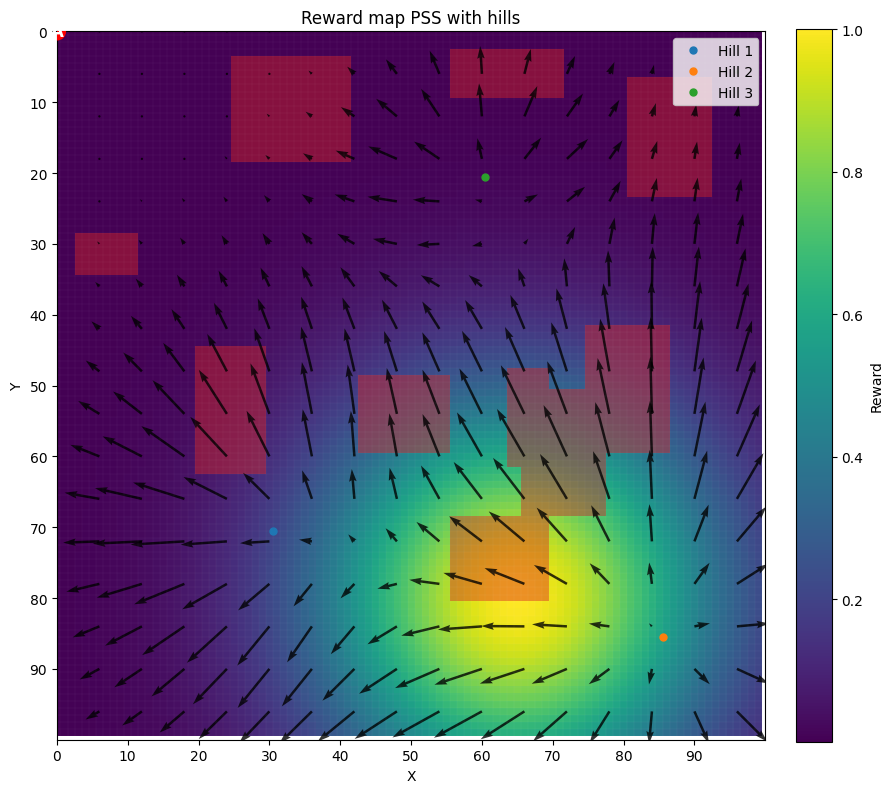

In [1]:
from pathlib import Path
from matplotlib.patches import Circle, Patch
import matplotlib.pyplot as plt
import sys
import numpy as np
from scipy.stats import multivariate_normal
import torch

start_state = (0, 0)

def plot_agent(location, ax=None, radius=1.2):
    x, y = location
    agent = Circle((x, y), radius=radius, color='red', zorder=3)
    ax.add_patch(agent)

    # Draw white 'A' in the center
    ax.text(
        x, y, 'A',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',    
        va='center',
        zorder=4
    )


# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import directly from module (not from src/__init__.py)
from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=64)
env.clear_hills()
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(85, 85), sigma=30.0, strength=100, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
env.plot_combined(ax=ax)
env.plot_hills(ax=ax)
ax.set_title("Reward map PSS with hills")
plot_agent(start_state, ax=ax)
plt.show()

x_top, y_top = env.reward_gaussian_mean
states_visited = {start_state: 1}

actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}

In [2]:
from src.q_learning import QLearningAgent

EPISODES = 5000
MAX_STEPS = 200
ALPHA = 0.3
GAMMA = 0.9
EPSILON = 1
EPSILON_DECAY = 0.9995
MIN_EPSILON = 0.2

agent = QLearningAgent(env, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON, 
                       epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON)

train_x, train_y = agent.train(start_state, episodes=EPISODES, max_steps=MAX_STEPS)

Training Episodes: 100%|██████████| 5000/5000 [06:09<00:00, 13.55it/s]


/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_34912/2529305707.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  action_cmap = plt.cm.get_cmap('tab10', 4)


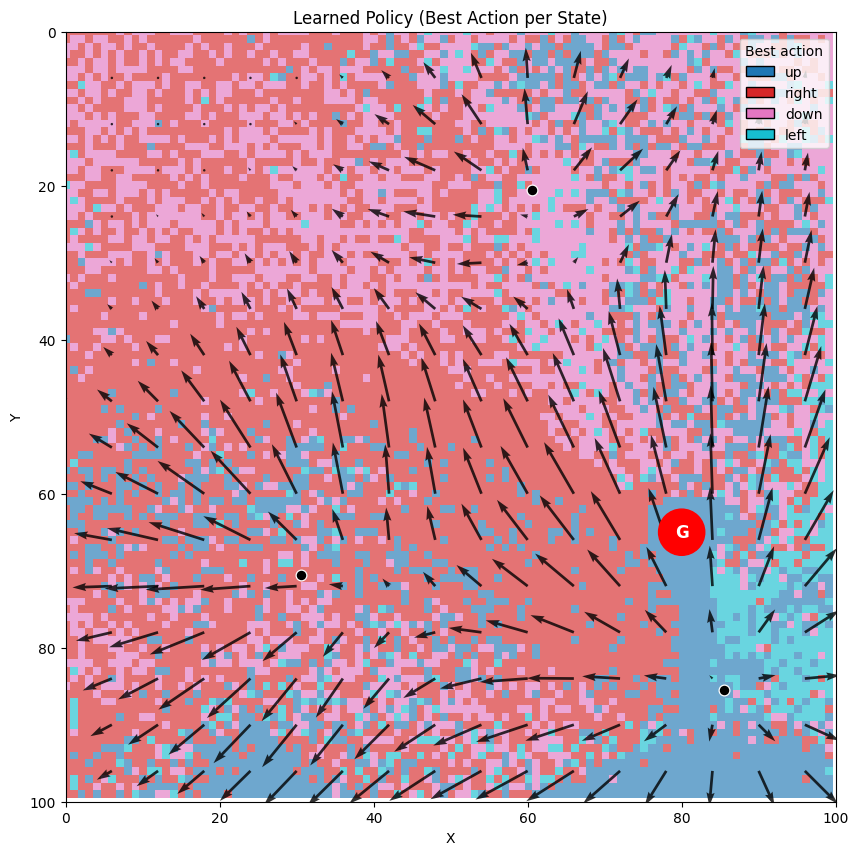

In [3]:
def plot_policy(Q, env, ax=None):
    max_x, max_y = env.grid_shape
    policy_grid = np.argmax(Q, axis=2)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    
    # Color each state by its best action (no policy arrows).
    # Use top-origin to match the rest of the environment visualizations (y=0 at top).
    action_cmap = plt.cm.get_cmap('tab10', 4)
    im = ax.imshow(
        policy_grid.T,
        cmap=action_cmap,
        origin='upper',
        interpolation='nearest',
        vmin=-0.5,
        vmax=3.5,
        alpha=0.65
    )
    
    # Keep hill vectors and hill-top markers on top.
    env.plot_hills(ax=ax, color='black')
    for top, *_ in env.hill_tops:
        tx, ty = top
        ax.scatter(tx + 0.5, ty + 0.5, s=60, c='black', edgecolors='white', linewidths=0.9, zorder=6)

    goal = Circle((x_top, y_top), radius=3, color='red', zorder=3)
    ax.add_patch(goal)

    # Draw white 'G' in the center
    ax.text(
        x_top, y_top, 'G',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    ) 
    
    
    action_labels = ['up', 'right', 'down', 'left']
    legend_handles = [
        Patch(facecolor=action_cmap(i), edgecolor='black', label=label)
        for i, label in enumerate(action_labels)
    ]
    ax.legend(handles=legend_handles, title='Best action', loc='upper right', frameon=True)
    
    ax.set_title('Learned Policy (Best Action per State)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.show()

def plot_run(Q, env, start_state, max_steps=1000, num_runs=1, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    env.plot_combined(ax=ax)
    env.plot_hills(ax=ax, color='black')

    plot_agent(start_state, ax=ax)
    

    goal = Circle((x_top, y_top), radius=2, color='green', zorder=3)
    ax.add_patch(goal)

    # Draw white 'G' in the center
    ax.text(
        x_top, y_top, 'G',
        color='white',
        fontsize=8,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    ) 

    colors = plt.cm.get_cmap('tab10', max(num_runs, 1))
    for run_idx in range(num_runs):
        s = start_state
        trajectory = [s]

        for _ in range(max_steps):
            x, y = s
            a_index = np.argmax(Q[x, y, :])
            a = list(actions.values())[a_index]
            s = env.transition(s, a)
            trajectory.append(s)

            if agent.distance_to_goal(s) < 5:
                break

        traj_x, traj_y = zip(*trajectory)
        ax.plot(
            traj_x, traj_y,
            marker='o',
            color=colors(run_idx),
            label=f'Run {run_idx + 1}' if num_runs > 1 else 'Agent Trajectory'
        )
    ax.legend()
    ax.set_title("Agent Trajectory Following Learned Q-values")
    plt.show()

fig, ax = plt.subplots(figsize=(10, 10))

Q = agent.get_q_values()

plot_policy(Q, env, ax=ax)


/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_34912/2529305707.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', max(num_runs, 1))


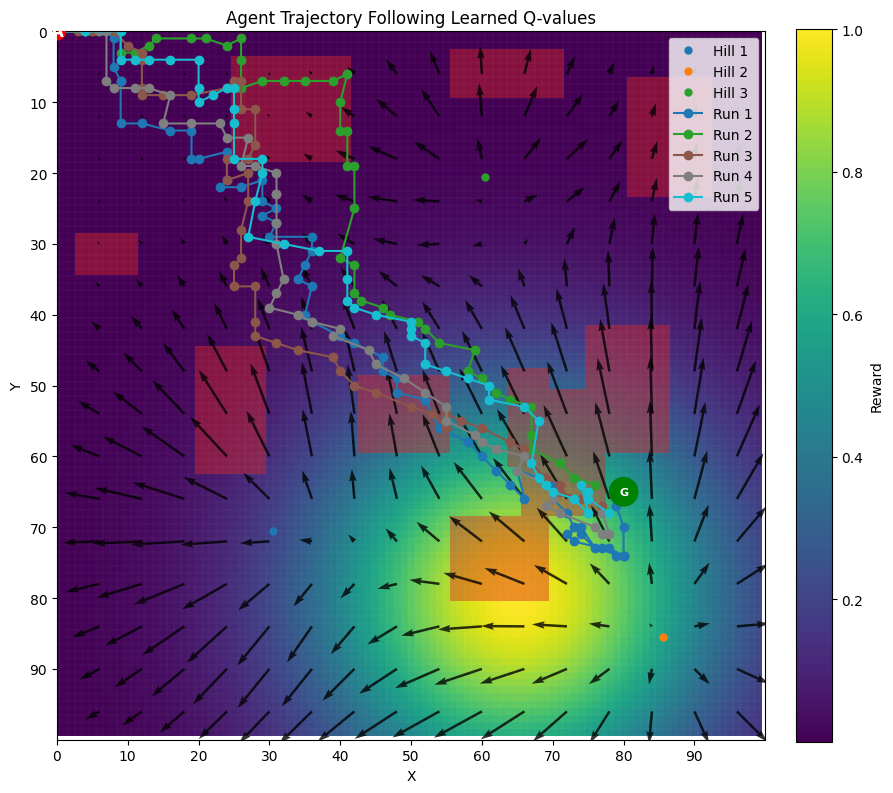

In [4]:

plot_run(Q, env, start_state, max_steps=MAX_STEPS, num_runs=5)

Iter 10/50 - Loss X: 5.222, Loss Y: 6.383
Iter 20/50 - Loss X: 4.710, Loss Y: 6.033
Iter 30/50 - Loss X: 4.618, Loss Y: 5.834
Iter 40/50 - Loss X: 4.538, Loss Y: 5.734
Iter 50/50 - Loss X: 4.497, Loss Y: 5.675


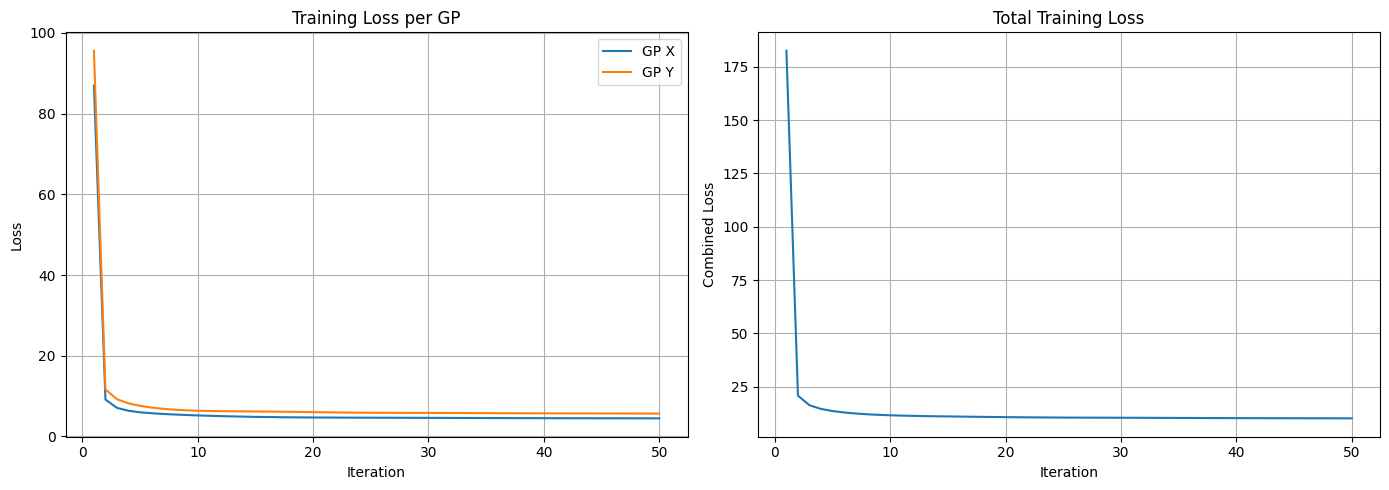

In [5]:
from src.GP import BoTorchDualSingleTaskGP

starting_pos = [(50, 50), (20, 20), (80, 80), (20, 80), (80, 20)]

train_x, train_y, states_visited = BoTorchDualSingleTaskGP.get_random_train_data(env=env, start_positions=starting_pos)
model = BoTorchDualSingleTaskGP(train_x, train_y)
losses_x, losses_y = model.fit(training_iterations=50, lr=0.1, verbose=True)

# Plot loss curves
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(range(1, len(losses_x) + 1), losses_x, label='GP X')
axs[0].plot(range(1, len(losses_y) + 1), losses_y, label='GP Y')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Loss')
axs[0].set_title('Training Loss per GP')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(range(1, len(losses_x) + 1), [lx + ly for lx, ly in zip(losses_x, losses_y)])
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Combined Loss')
axs[1].set_title('Total Training Loss')
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# takes very long
def plot_ll_heatmap(model, 
                    start_positions, 
                    env, 
                    actions, 
                    grid_resolution=100, 
                    n_samples_per_cell=50, 
                    threshold=-10,
                    red_max=-2,
                    ax=None
                    ):
    """
    Plot log-likelihood heatmap for BoTorchDualSingleTaskGP model.
    Uses model.predict() to get mean and covariance.
    """
    from matplotlib.colors import LinearSegmentedColormap

    x_coords = np.linspace(0, 99, grid_resolution)
    y_coords = np.linspace(0, 99, grid_resolution)

    log_likelihood_map = np.zeros((grid_resolution, grid_resolution))

    model.eval()

    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            state = (int(x), int(y))
            total_log_prob = 0
            
            for action_name, action in actions.items():
                # Get GP prediction using new predict method
                x_input = torch.tensor([[state[0], state[1], action[0], action[1]]], dtype=torch.float64)
                pred_mean, pred_cov = model.predict(x_input)
                pred_mean = pred_mean.squeeze()  # (2,)
                pred_cov = pred_cov  # (2, 2)
                
                # Sample from real environment and compute log prob under GP
                for _ in range(n_samples_per_cell):
                    next_state = env.transition(state, action)
                    next_state_tensor = torch.tensor([next_state[0], next_state[1]], dtype=torch.float64)
                    
                    # Create distribution and compute log prob
                    try:
                        dist = torch.distributions.MultivariateNormal(pred_mean, pred_cov)
                        log_prob = dist.log_prob(next_state_tensor).item()
                    except:
                        # If covariance is not positive definite, use diagonal approximation
                        log_prob = -10  # penalty for numerical issues
                    
                    total_log_prob += log_prob
            
            # Average log likelihood for this cell
            log_likelihood_map[j, i] = total_log_prob / (len(actions) * n_samples_per_cell)
        
        if (i + 1) % 10 == 0:
            print(f"Processed row {i+1}/{grid_resolution}")

    # Create custom colormap: viridis for values <= threshold, red gradient for > threshold
    vmin, vmax = log_likelihood_map.min(), log_likelihood_map.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Plot main heatmap with viridis for values below threshold
    plot_data_viridis = np.where(log_likelihood_map <= threshold, log_likelihood_map, np.nan)
    im = ax.imshow(plot_data_viridis, cmap='viridis', origin='lower', 
                extent=[0, 100, 0, 100], aspect='equal', vmin=vmin, vmax=threshold)

    # Create red gradient colormap (light red to dark red)
    reds_cmap = LinearSegmentedColormap.from_list('custom_reds', ['#ffcccc', '#ff0000', '#8b0000'])

    # Plot red gradient for values > threshold
    plot_data_red = np.where(log_likelihood_map > threshold, log_likelihood_map, np.nan)
    im_red = ax.imshow(plot_data_red, cmap=reds_cmap, origin='lower', 
                    extent=[0, 100, 0, 100], aspect='equal', vmin=threshold, vmax=red_max)

    # Add colorbars
    plt.colorbar(im, ax=ax, label='Log Likelihood (poor)', location='left', pad=0.12)
    plt.colorbar(im_red, ax=ax, label='Log Likelihood (good)', location='right')

    # Mark training start positions
    for pos in start_positions:
        ax.plot(pos[0], pos[1], 'w*', markersize=15, markeredgecolor='black', markeredgewidth=1)

    env.plot_hills(ax=ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'GP Model Log Likelihood Heatmap\n(White stars = training start positions)')

    good_mask = log_likelihood_map > threshold
    print(f"\nLog likelihood statistics:")
    print(f"  Min: {log_likelihood_map.min():.2f}")
    print(f"  Max: {log_likelihood_map.max():.2f}")
    print(f"  Mean: {log_likelihood_map.mean():.2f}")
    print(f"  Cells with LL > {threshold}: {good_mask.sum()} / {log_likelihood_map.size}")
    
    return ax, log_likelihood_map


def plot_ll_heatmap_simple(model, 
                           start_positions, 
                           env, 
                           actions, 
                           grid_resolution=100, 
                           n_samples_per_cell=50, 
                           cmap='RdYlGn',
                           vmin=None,
                           vmax=None,
                           ax=None,
                           show_hills=True,
                           show_start_positions=True,
                           colorbar_label='Log Likelihood'
                           ):
    """
    Simple log-likelihood heatmap with single colormap and adjustable colors.
    
    Args:
        model: BoTorchDualSingleTaskGP model
        start_positions: list of (x, y) training start positions
        env: environment for sampling transitions
        actions: dict of action name -> action tuple
        grid_resolution: number of grid cells per axis
        n_samples_per_cell: samples per cell for LL estimation
        cmap: colormap name or LinearSegmentedColormap (e.g. 'viridis', 'RdYlGn', 'coolwarm')
        vmin: minimum value for colormap (None = auto)
        vmax: maximum value for colormap (None = auto)
        ax: matplotlib axes (creates new if None)
        show_hills: whether to overlay hill contours
        show_start_positions: whether to mark training start positions
        colorbar_label: label for the colorbar
    
    Returns:
        ax, log_likelihood_map
    """
    from matplotlib.colors import LinearSegmentedColormap

    x_coords = np.linspace(0, 99, grid_resolution)
    y_coords = np.linspace(0, 99, grid_resolution)

    log_likelihood_map = np.zeros((grid_resolution, grid_resolution))

    model.eval()

    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            state = (int(x), int(y))
            total_log_prob = 0
            
            for action_name, action in actions.items():
                x_input = torch.tensor([[state[0], state[1], action[0], action[1]]], dtype=torch.float64)
                pred_mean, pred_cov = model.predict(x_input)
                pred_mean = pred_mean.squeeze()
                
                for _ in range(n_samples_per_cell):
                    next_state = env.transition(state, action)
                    next_state_tensor = torch.tensor([next_state[0], next_state[1]], dtype=torch.float64)
                    
                    try:
                        dist = torch.distributions.MultivariateNormal(pred_mean, pred_cov)
                        log_prob = dist.log_prob(next_state_tensor).item()
                    except:
                        log_prob = -10
                    
                    total_log_prob += log_prob
            
            log_likelihood_map[j, i] = total_log_prob / (len(actions) * n_samples_per_cell)
        
        if (i + 1) % 10 == 0:
            print(f"Processed row {i+1}/{grid_resolution}")

    # Use provided bounds or auto-detect
    plot_vmin = vmin if vmin is not None else log_likelihood_map.min()
    plot_vmax = vmax if vmax is not None else log_likelihood_map.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Single colormap for entire range
    im = ax.imshow(log_likelihood_map, cmap=cmap, origin='lower', 
                   extent=[0, 100, 0, 100], aspect='equal', 
                   vmin=plot_vmin, vmax=plot_vmax)

    plt.colorbar(im, ax=ax, label=colorbar_label)

    if show_start_positions:
        for pos in start_positions:
            ax.plot(pos[0], pos[1], 'w*', markersize=15, markeredgecolor='black', markeredgewidth=1)

    if show_hills:
        env.plot_hills(ax=ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('GP Model Log Likelihood Heatmap')

    print(f"\nLog likelihood statistics:")
    print(f"  Min: {log_likelihood_map.min():.2f}")
    print(f"  Max: {log_likelihood_map.max():.2f}")
    print(f"  Mean: {log_likelihood_map.mean():.2f}")
    
    return ax, log_likelihood_map


def plot_visited_overlay(states_visited, ax=None, color='blue', min_alpha=0.1, max_alpha=0.9, show_colorbar=True):
    """
    Plot a transparent overlay showing how often states were visited.
    Alpha scales with visit count - more visits = more opaque.
    
    Args:
        states_visited: dict mapping (x, y) tuples to visit counts
        ax: matplotlib axes to overlay on
        color: single color for all visited states (name or hex)
        min_alpha: minimum alpha for least visited states
        max_alpha: maximum alpha for most visited states
        show_colorbar: whether to add a colorbar showing visit counts
    """
    from matplotlib.colors import to_rgba
    
    grid_size = 100
    visit_counts = np.zeros((grid_size, grid_size))
    
    for state, count in states_visited.items():
        x, y = state
        if 0 <= x < grid_size and 0 <= y < grid_size:
            visit_counts[y, x] = count
    
    # Get max visits for normalization
    max_visits = visit_counts.max()
    if max_visits == 0:
        return ax
    
    # Create RGBA image: same color everywhere, alpha scales with visit count
    base_color = to_rgba(color)[:3]  # Get RGB without alpha
    
    # Normalize visit counts to [0, 1]
    normalized_counts = visit_counts / max_visits
    
    # Scale alpha: 0 visits -> 0 alpha, max visits -> max_alpha
    # For visited cells, scale between min_alpha and max_alpha
    alpha_map = np.where(visit_counts > 0, 
                         min_alpha + normalized_counts * (max_alpha - min_alpha),
                         0)
    
    # Create RGBA array
    rgba_image = np.zeros((grid_size, grid_size, 4))
    rgba_image[:, :, 0] = base_color[0]  # R
    rgba_image[:, :, 1] = base_color[1]  # G
    rgba_image[:, :, 2] = base_color[2]  # B
    rgba_image[:, :, 3] = alpha_map      # A (scaled by visit count)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.imshow(rgba_image, origin='lower', extent=[0, 100, 0, 100], aspect='equal')
    
    if show_colorbar:
        # Create a fake ScalarMappable for the colorbar to show visit counts
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize as mplNormalize
        
        # Create a colormap that goes from transparent to solid color
        from matplotlib.colors import LinearSegmentedColormap
        cmap_alpha = LinearSegmentedColormap.from_list(
            'alpha_scale', 
            [(base_color[0], base_color[1], base_color[2], min_alpha),
             (base_color[0], base_color[1], base_color[2], max_alpha)]
        )
        sm = cm.ScalarMappable(cmap=cmap_alpha, norm=mplNormalize(vmin=1, vmax=max_visits))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='Visit Count', shrink=0.6)
    
    return ax

Processed row 10/50
Processed row 20/50
Processed row 30/50
Processed row 40/50
Processed row 50/50

Log likelihood statistics:
  Min: -24.61
  Max: -2.87
  Mean: -6.34


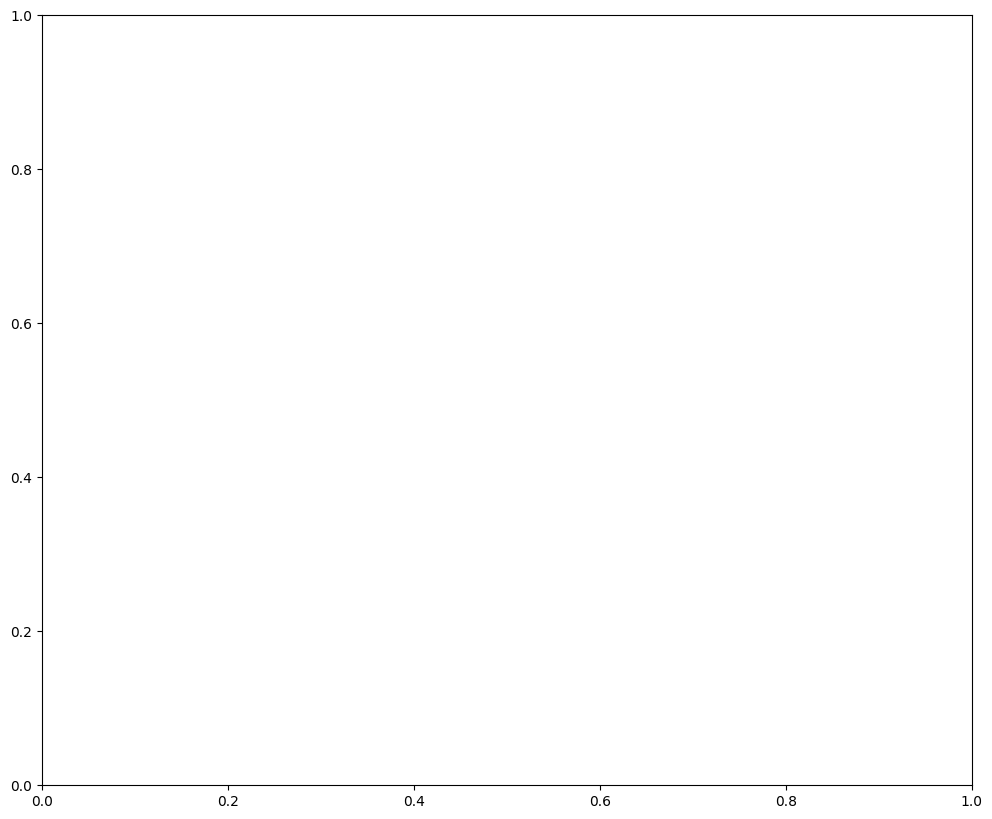

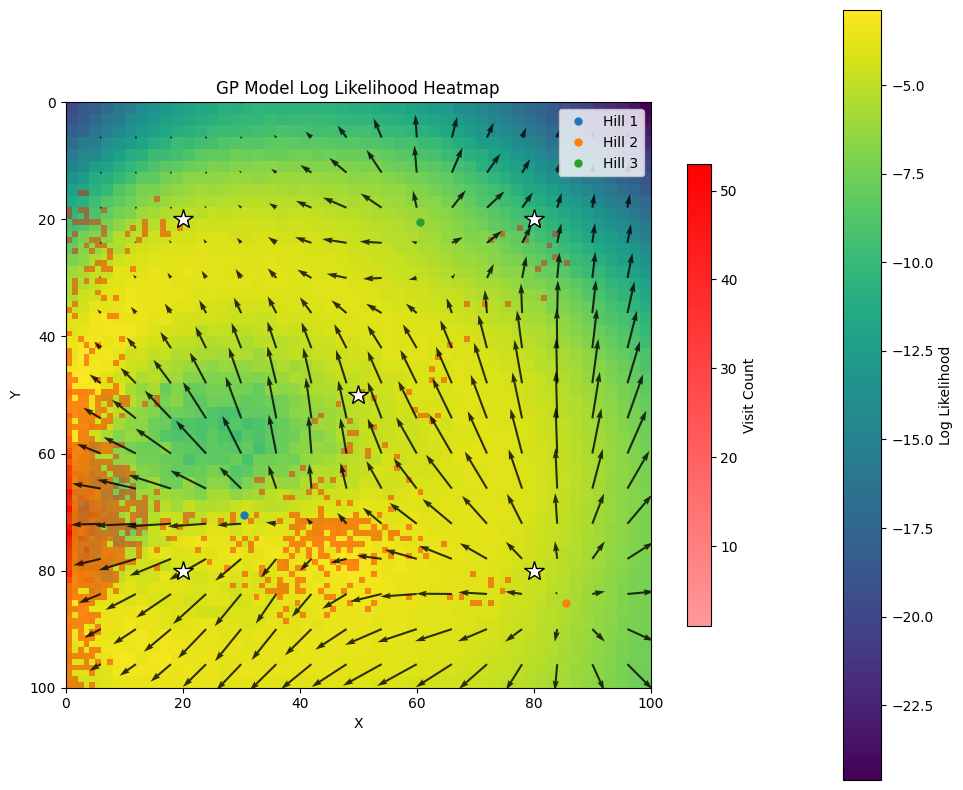

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
ax, ll_map = plot_ll_heatmap_simple(
    model, starting_pos, env, actions,
    grid_resolution=50, 
    n_samples_per_cell=20,
    cmap='viridis'
)
plot_visited_overlay(states_visited, ax, color='red', max_alpha=1.0, min_alpha=0.4)
plt.tight_layout()
plt.show()

In [8]:
max_x, max_y = env.grid_shape

pred_mean_with_policy = np.zeros((max_x, max_y, 2), dtype=np.float64)      # [x, y, mean_x, mean_y]
pred_cov_with_policy  = np.zeros((max_x, max_y, 2, 2), dtype=np.float64)   # [x, y, cov(2x2)]

action_list = list(actions.values())

for x in range(max_x):
    for y in range(max_y):
        best_action_index = np.argmax(Q[x, y, :])
        best_action = action_list[best_action_index]

        x_input = torch.tensor([[x, y, best_action[0], best_action[1]]], dtype=torch.float64)
        pred_mean, pred_cov = model.predict(x_input)

        mean_np = pred_mean.squeeze(0).detach().cpu().numpy()   # shape (2,)
        cov_np  = pred_cov.detach().cpu().numpy()               # shape (2,2)

        pred_mean_with_policy[x, y] = mean_np
        pred_cov_with_policy[x, y] = cov_np

In [9]:
from scipy.stats import norm

def transition_prob_policy(state, next_state, pred_mean_with_policy=pred_mean_with_policy, pred_cov_with_policy=pred_cov_with_policy, grid_shape=(100, 100)):
    x, y = state
    nx, ny = next_state
    max_x, max_y = grid_shape
    
    # Bounds check for current state
    if not (0 <= x < max_x and 0 <= y < max_y):
        return 0.0
    
    # Bounds check for next state (must be valid cell)
    if not (0 <= nx < max_x and 0 <= ny < max_y):
        return 0.0
    
    # Get predicted mean and covariance for this state
    mean = pred_mean_with_policy[x, y]      # shape (2,): [mean_x, mean_y]
    cov = pred_cov_with_policy[x, y]        # shape (2, 2): diagonal covariance
    
    # Extract standard deviations (covariance is diagonal)
    std_x = np.sqrt(cov[0, 0])
    std_y = np.sqrt(cov[1, 1])
    
    mean_x, mean_y = mean[0], mean[1]
    
    # Define cell boundaries for x-coordinate
    # Cell 0 absorbs everything < 0.5 (due to clipping + rounding)
    # Cell max_x-1 absorbs everything >= max_x-1 - 0.5
    if nx == 0:
        x_lo, x_hi = -np.inf, 0.5
    elif nx == max_x - 1:
        x_lo, x_hi = nx - 0.5, np.inf
    else:
        x_lo, x_hi = nx - 0.5, nx + 0.5
    
    # Define cell boundaries for y-coordinate
    if ny == 0:
        y_lo, y_hi = -np.inf, 0.5
    elif ny == max_y - 1:
        y_lo, y_hi = ny - 0.5, np.inf
    else:
        y_lo, y_hi = ny - 0.5, ny + 0.5
    
    # Compute probability mass using CDF differences
    # P(x in [lo, hi]) = Φ((hi - μ)/σ) - Φ((lo - μ)/σ)
    p_x = norm.cdf(x_hi, loc=mean_x, scale=std_x) - norm.cdf(x_lo, loc=mean_x, scale=std_x)
    p_y = norm.cdf(y_hi, loc=mean_y, scale=std_y) - norm.cdf(y_lo, loc=mean_y, scale=std_y)
    
    # Since x and y are independent (diagonal covariance), joint probability is product
    return p_x * p_y

total = 0.0

for x in range(max_x):
    for y in range(max_y):
        total += transition_prob_policy((99,99), (x, y), pred_mean_with_policy, pred_cov_with_policy, grid_shape=(max_x, max_y))

print(total)

1.0000000000000002


In [10]:
# dp = np.array([[[None] for _ in range(max_x)]
#       for _ in range(max_y)])

# print(dp.shape)

# def x(state, q, pred_mean_with_policy=pred_mean_with_policy, pred_cov_with_policy=pred_cov_with_policy, grid_shape=(100, 100), dp=None):

#     s_x, s_y = state

#     if dp is None:
#         dp = {}

#     if (s_x, s_y) in dp:
#         return dp[s_x, s_y]

#     if (s_x, s_y) in q:
#         dp[s_x, s_y] = 1.0
#         return 1.0

#     value = 0.0
#     if (s_x, s_y) in q:
#         return 1.0
#     else:
#         value = 0.0
#         for i in range(grid_shape[0]):
#             for j in range(grid_shape[1]):
#                 if (i, j) in q:
#                     value += transition_prob_policy(state, 
#                                                     (i, j), 
#                                                     pred_mean_with_policy, 
#                                                     pred_cov_with_policy, 
#                                                     grid_shape=grid_shape)
#                 else:
#                     value += transition_prob_policy(state, 
#                                                     (i, j), 
#                                                     pred_mean_with_policy, 
#                                                     pred_cov_with_policy, 
#                                                     grid_shape=grid_shape) * x((i, j), q, pred_mean_with_policy, pred_cov_with_policy, grid_shape, dp)
                    
#     dp[s_x, s_y] = value

# for i in range(max_x):
#     for j in range(max_y):
#         if i==1 and j == 0:
#             print(f"Computing x for state ({i}, {j})...")
#         if i%10 == 0 and j == 0:
#             print(f"Computing x for state ({i}, {j})...")
#         x((i, j), states_visited, pred_mean_with_policy, pred_cov_with_policy, grid_shape=(max_x, max_y), dp=dp)


In [16]:
from scipy.stats import norm
import numpy as np

S_q = np.array(np.argwhere(~env.unsafe_mask).tolist())
q = np.array(np.argwhere(env.unsafe_mask).tolist())
S = np.array([(s_x, s_y) for s_x in range(max_x) for s_y in range(max_y)])

N = len(S)  # 8439
M = len(S)  # 8439

pred_mean_with_policy = np.array(pred_mean_with_policy)  # shape (100, 100, 2)
pred_cov_with_policy = np.array(pred_cov_with_policy)    # shape (100, 100, 2, 2)

means = pred_mean_with_policy[S[:,0], S[:,1]]   # (N,2)
covs  = pred_cov_with_policy[S[:,0], S[:,1]]    # (N,2,2)

mean_x = means[:, 0][:, None]   # (N,1)
mean_y = means[:, 1][:, None]

std_x = np.sqrt(covs[:, 0, 0])[:, None]
std_y = np.sqrt(covs[:, 1, 1])[:, None]

nx = S[:, 0][None, :]   # (1,M)
ny = S[:, 1][None, :]

x_lo = np.where(nx == 0, -np.inf,
                np.where(nx == max_x-1, nx - 0.5, nx - 0.5))

x_hi = np.where(nx == 0, 0.5,
                np.where(nx == max_x-1, np.inf, nx + 0.5))

y_lo = np.where(ny == 0, -np.inf,
                np.where(ny == max_y-1, ny - 0.5, ny - 0.5))

y_hi = np.where(ny == 0, 0.5,
                np.where(ny == max_y-1, np.inf, ny + 0.5))

p_x = norm.cdf(x_hi, loc=mean_x, scale=std_x) - norm.cdf(x_lo, loc=mean_x, scale=std_x)

p_y = norm.cdf(y_hi, loc=mean_y, scale=std_y) - norm.cdf(y_lo, loc=mean_y, scale=std_y)

A = p_x * p_y

In [17]:
N = len(S_q)   # 8439
M = len(q)     # 1561

means = pred_mean_with_policy[S_q[:,0], S_q[:,1]]
covs  = pred_cov_with_policy[S_q[:,0], S_q[:,1]]

mean_x = means[:, 0][:, None]
mean_y = means[:, 1][:, None]

std_x = np.sqrt(covs[:, 0, 0])[:, None]
std_y = np.sqrt(covs[:, 1, 1])[:, None]

nx = q[:, 0][None, :]
ny = q[:, 1][None, :]

p_x = norm.cdf(x_hi, loc=mean_x, scale=std_x) - norm.cdf(x_lo, loc=mean_x, scale=std_x)

p_y = norm.cdf(y_hi, loc=mean_y, scale=std_y) - norm.cdf(y_lo, loc=mean_y, scale=std_y)

b_ = (p_x * p_y).sum(axis=1)

Processing state (0, 0)
Processing state (10, 0)
Processing state (20, 0)
Processing state (30, 0)
Processing state (40, 0)
Processing state (50, 0)
Processing state (60, 0)
Processing state (70, 0)
Processing state (80, 0)
Processing state (90, 0)


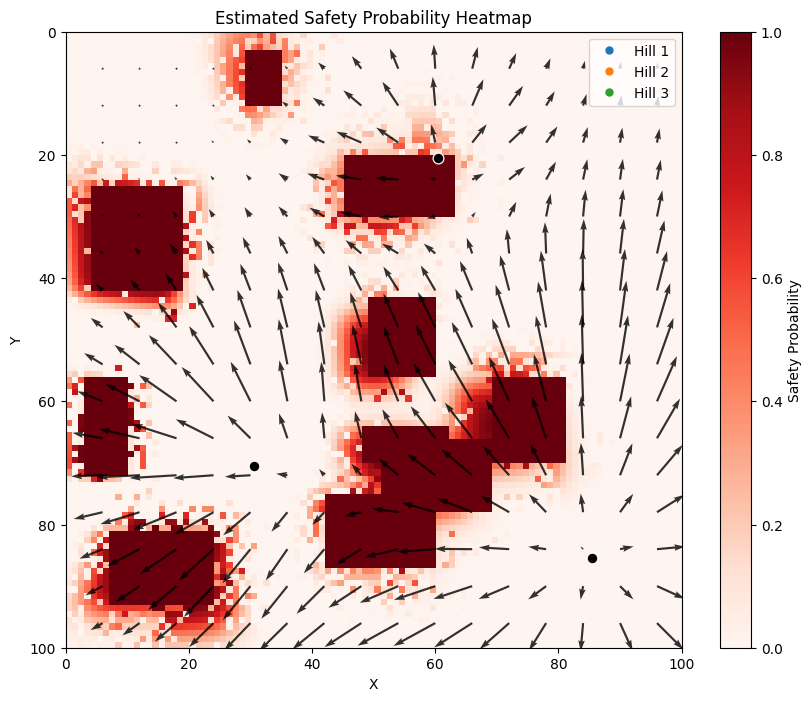

In [ ]:
# from tqdm import tqdm

# q = env.unsafe_mask

# unsafe_indices = np.argwhere(q).tolist()

# x = env.unsafe_mask.astype(np.float64)  # 1 for unsafe, 0 for safe


# x_new = np.zeros((max_x, max_y), dtype=np.float64)
# for i in range(max_x):
#     for j in range(max_y):

#         if i%10 == 0 and j == 0:
#             print(f"Processing state ({i}, {j})")

#         if [i, j] in unsafe_indices:
#             x_new[i, j] = 1.0
#         else:
#             # Sum over all successor states
#             for i2 in range(max_x):
#                 for j2 in range(max_y):
#                     if [i2, j2] in unsafe_indices:
#                         x_new[i, j] += transition_prob_policy((i, j), (i2, j2), pred_mean_with_policy, pred_cov_with_policy, grid_shape=(max_x, max_y))
#                     else:
#                         x_new[i, j] += transition_prob_policy((i, j), (i2, j2), pred_mean_with_policy, pred_cov_with_policy, grid_shape=(max_x, max_y)) * x_new[i2, j2]

                   
# x = x_new

def plot_safety_heatmap(safety_map, env, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(safety_map.T, origin='lower', extent=[0, 100, 0, 100], aspect='equal', cmap='Reds', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Safety Probability')
    
    env.plot_hills(ax=ax)
    
    for top, *_ in env.hill_tops:
        tx, ty = top
        ax.scatter(tx + 0.5, ty + 0.5, s=60, c='black', edgecolors='white', linewidths=0.9, zorder=6)


# fig, ax = plt.subplots(figsize=(10, 8))
# plot_safety_heatmap(x, env, ax=ax)
# ax.set_title('Estimated Safety Probability Heatmap')
# plt.show()
    


/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_30141/2529305707.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  action_cmap = plt.cm.get_cmap('tab10', 4)


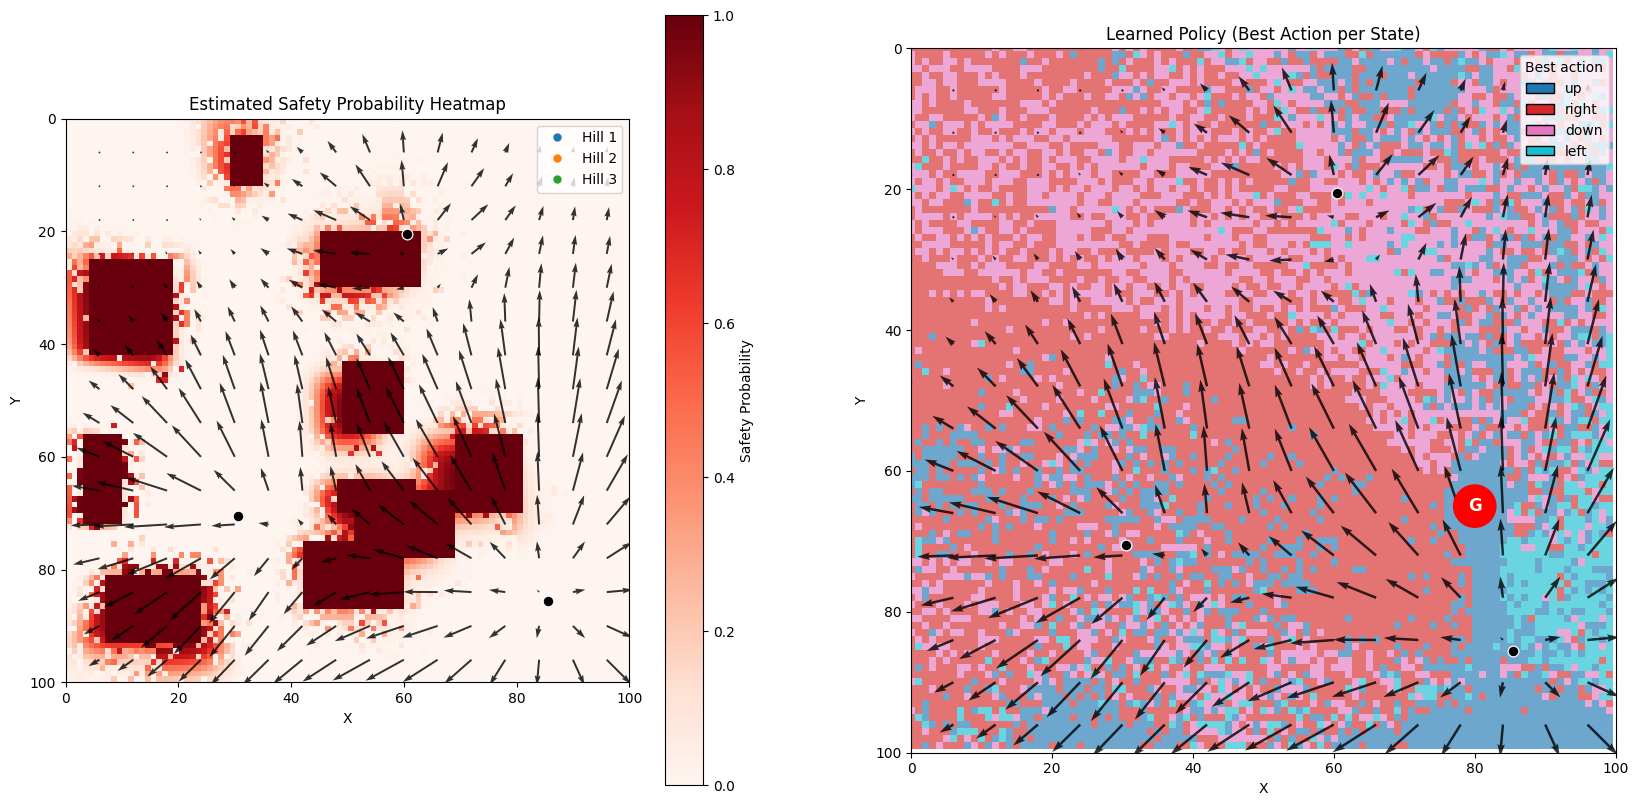

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
plot_safety_heatmap(x, env, ax=axs[0])
axs[0].set_title('Estimated Safety Probability Heatmap')
plot_policy(Q, env, ax=axs[1])
env.plot_unsafe_mask(ax=axs[1])
axs[1].set_title('Learned Policy (Best Action per State)')
plt.show()